In [1]:
# --- Install required libraries ---
!pip install torch torchvision torchmetrics[image] matplotlib medmnist pytorch-fid --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 131.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 74.1 MB/s eta 0:0

In [2]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import ConcatDataset
from torchvision.utils import make_grid
import torch.nn.utils as utils
from torch.utils.tensorboard import SummaryWriter
from torchvision.models.feature_extraction import get_graph_node_names
from torchvision.models import inception_v3
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision.utils import save_image
import os
import itertools
import json

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import torchvision.transforms.functional as F

import medmnist
from medmnist import INFO, Evaluator

In [3]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/ColabNotebooks/TP2

project_path = '/content/drive/MyDrive/ColabNotebooks/TP2/cGAN'

model_dir = os.path.join(project_path, 'models')  # Directory to save all the best models
best_models = os.path.join(model_dir, 'best_models')  # Directory to save the best models of the base model
checkpoints = os.path.join(model_dir, 'checkpoints')  # Directory to save the checkpoints of the base model
best_grid_models = os.path.join(model_dir, 'best_grid_models')  # Directory to save the best models found during the grid search
grid_checkpoints = os.path.join(model_dir, 'grid_checkpoints')  # Directory to save checkpoints during the grid search
images_dir = os.path.join(project_path, 'generated_images')  # Directory to save the generated images
logs_dir = os.path.join(project_path, 'logs')

os.makedirs(model_dir, exist_ok=True)
os.makedirs(best_models, exist_ok=True)
os.makedirs(checkpoints, exist_ok=True)
os.makedirs(best_grid_models, exist_ok=True)
os.makedirs(grid_checkpoints, exist_ok=True)
os.makedirs(images_dir, exist_ok=True)
os.makedirs(logs_dir, exist_ok=True)

Mounted at /content/drive
/content/drive/MyDrive/ColabNotebooks/TP2


In [ ]:
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/


# BloodMNIST Dataset Configuration and Initialization

In [4]:
data_flag = 'bloodmnist'
download = True
BATCH_SIZE = 128

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

# Preprocessing and Data Loading


*   **Resize to 64×64**: Required for FID calculation, which uses an Inception model expecting inputs of at least 64×64.
*   **Normalize to [-1, 1]**: Helps stabilize GAN training by mapping pixel values from [0, 1] to [-1, 1].



In [5]:
# Preprocessing - Sequence of image transformations to apply to each input image
data_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load all splits of the dataset with the specified transformations
train = DataClass(split='train', transform=data_transform, download=True)
val = DataClass(split='val', transform=data_transform, download=True)
test = DataClass(split='test', transform=data_transform, download=True)

# Combine the train, validation, and test datasets into one full dataset
full_dataset = ConcatDataset([train, val, test])

# Set the batch size depending on the availability of a GPU
batch_size = 256 if torch.cuda.is_available() else 128

# Create a DataLoader to load data from the full dataset in mini-batches
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)

# Initialize a TensorBoard SummaryWriter to log training metrics and visualizations
writer = SummaryWriter(logs_dir)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

100%|██████████| 35.5M/35.5M [00:04<00:00, 7.95MB/s]


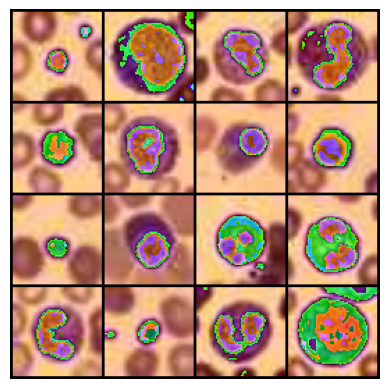

In [ ]:
# Visualization
# Get a few samples
samples = [full_dataset[i][0] for i in range(16)]  # assuming (image, label) tuples

# Make a grid
grid = make_grid(samples, nrow=4)

# Display
plt.imshow(F.to_pil_image(grid))
plt.axis('off')
plt.show()

## Conditional Generator

This implementation defines the **Generator** module for a Conditional Deep Convolutional Generative Adversarial Network (cDCGAN) in PyTorch. The generator takes as input a random noise vector `z` and a class label, and produces a synthetic image conditioned on that class.

### Key Features:
- **Conditional input**: The generator uses a learned embedding to map class labels into a continuous space (`nn.Embedding`), which is concatenated with the latent noise vector.
- **Latent vector dimension**: `z_dim = 100`
- **Label embedding dimension**: `embed_size = 100`
- **Number of classes**: `num_classes = 8` (e.g., for BloodMNIST dataset)
- **Image output shape**: `3 x 64 x 64` (RGB image)
- **Architecture**:
  - Series of `ConvTranspose2d` layers with BatchNorm and ReLU activations.
  - Final layer uses `Tanh()` to output image pixel values in the range `[-1, 1]`.

### Architecture Details:
- Input: noise vector (z) concatenated with label embedding → reshaped to (batch_size, input_dim, 1, 1)
- Layers:
  1. ConvTranspose2d: (z_dim + embed_size) → `feature_maps * 8`, kernel=4, stride=1
  2. ConvTranspose2d: `feature_maps * 8` → `feature_maps * 4`, kernel=4, stride=2
  3. ConvTranspose2d: `feature_maps * 4` → `feature_maps * 2`, kernel=4, stride=2
  4. ConvTranspose2d: `feature_maps * 2` → `feature_maps`, kernel=4, stride=2
  5. ConvTranspose2d: `feature_maps` → `img_channels`, kernel=4, stride=2

### Weight Initialization:
Uses the `weights_init_dcgan` function:
- Conv layers: initialized with `Normal(0.0, 0.02)`
- BatchNorm layers: weights initialized with `Normal(1.0, 0.02)`, biases set to 0


In [6]:
def weights_init_dcgan(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3, feature_maps=64, num_classes=8, embed_size=100):
        super(Generator, self).__init__()
        self.z_dim = z_dim
        self.embed = nn.Embedding(num_classes, embed_size)

        # Projected input size after concatenation: z_dim + embed_size
        input_dim = z_dim + embed_size

        self.model = nn.Sequential(
            nn.ConvTranspose2d(input_dim, feature_maps * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_maps * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps * 8, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

        self.initialize_weights()

    def initialize_weights(self):
        self.model.apply(weights_init_dcgan)

    def forward(self, noise, labels):
        # Embed and concatenate
        label_embedding = self.embed(labels)  # Shape: (batch_size, embed_size)
        x = torch.cat([noise, label_embedding], dim=1)  # Shape: (batch_size, z_dim + embed_size)

        # Reshape to match ConvTranspose2d input: (batch_size, channels, 1, 1)
        x = x.view(x.size(0), x.size(1), 1, 1)
        return self.model(x)


## Conditional Discriminator

This implementation defines the **Discriminator** module for a Conditional Deep Convolutional GAN (cDCGAN). The discriminator receives an image and a class label and learns to distinguish between real and fake images **conditioned** on the class.

### Key Features:
- **Conditional input**: The class label is embedded into a 2D tensor and concatenated as an additional image channel.
- **Spectral Normalization**: All convolutional layers use spectral normalization (`utils.spectral_norm`) to stabilize training.
- **No sigmoid in final layer**: The final output is raw logits, intended for use with `BCEWithLogitsLoss`.

### Label Conditioning:
- The class label is embedded via `nn.Embedding(num_classes, 64*64)` to produce a 2D tensor of shape `(1, 64, 64)`.
- This label tensor is concatenated to the input image (as an extra channel), so the network input becomes `(batch_size, img_channels + 1, 64, 64)`.

### Architecture Details:
- Input: image + label embedding → shape: `(B, 4, 64, 64)` (assuming RGB images)
- Layers:
  1. Conv2d: `img_channels + 1` → `feature_maps`, kernel=4, stride=2
  2. Conv2d: `feature_maps` → `feature_maps * 2`, kernel=4, stride=2
  3. Conv2d: `feature_maps * 2` → `feature_maps * 4`, kernel=4, stride=2
  4. Conv2d: `feature_maps * 4` → `feature_maps * 8`, kernel=4, stride=2
  5. Conv2d: `feature_maps * 8` → 1, kernel=4, stride=1

- Activations: LeakyReLU (with slope 0.2) after each layer except the last.
- Final output: Flattened tensor of shape `(batch_size,)` containing real/fake logits.

### Notes:
- Uses `BCEWithLogitsLoss` for stability and better numerical performance.
- Suitable for training alongside the conditional generator defined above.


In [7]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3, feature_maps=64, num_classes=8):
        super(Discriminator, self).__init__()
        self.num_classes = num_classes
        self.img_channels = img_channels

        # Label embedding: convert class index to a (64x64) image-like tensor
        self.label_embed = nn.Embedding(num_classes, 64 * 64)

        self.model = nn.Sequential(
            utils.spectral_norm(nn.Conv2d(img_channels + 1, feature_maps, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            utils.spectral_norm(nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            utils.spectral_norm(nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            utils.spectral_norm(nn.Conv2d(feature_maps * 4, feature_maps * 8, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            utils.spectral_norm(nn.Conv2d(feature_maps * 8, 1, 4, 1, 0, bias=False)),
            # No Sigmoid because BCEWithLogitsLoss will be used
        )

    def forward(self, images, labels):
        # Embed labels and reshape to match image spatial dimensions
        label_embeddings = self.label_embed(labels)                  # (B, 64*64)
        label_embeddings = label_embeddings.view(-1, 1, 64, 64)      # (B, 1, 64, 64)

        # Concatenate label as an extra channel
        x = torch.cat([images, label_embeddings], dim=1)             # (B, C+1, 64, 64)
        return self.model(x).view(-1)


### FID Evaluation Function (`compute_fid_safe`)

This function computes the **Fréchet Inception Distance (FID)** between real and generated images to quantitatively assess the visual quality and diversity of a GAN's output, using the `torchmetrics.image.FrechetInceptionDistance` class.

FID compares the distribution of real images to that of generated images in the feature space of a pretrained Inception network. Lower FID indicates higher image quality and closer resemblance to real data.


#### **Function Parameters**:
- `generator` (`nn.Module`): The conditional generator model to evaluate.
- `num_classes` (`int`): Number of classes in the dataset (used for label sampling).
- `num_samples` (`int`, default=`10_000`): Total number of real and fake images to compare.
- `batch_size` (`int`, default=`256`): Batch size used during FID updates.
- `z_dim` (`int`, default=`100`): Dimensionality of the latent noise vector input to the generator.


#### **Real Image Processing**:
- Loads real samples from `full_dataset` using a `DataLoader`.
- Rescales image pixel values from `[-1, 1]` to `[0, 1]`, matching the InceptionV3 input range.
- Adds batches to the FID object as real samples.
- Stops once `num_samples` real images have been processed.

> **Note**: `full_dataset` must be defined globally and should provide images normalized to `[-1, 1]`.


#### **Fake Image Generation**:
- Repeats until `num_samples` fake images are created and evaluated.
- Randomly samples noise vectors `z` and class labels.
- Passes inputs to the generator (in `eval()` mode with `torch.no_grad()`).
- Scales generated images from `[-1, 1]` to `[0, 1]` to match real image preprocessing.
- Updates FID stats with generated images as fake data.


#### **Memory and Performance Management**:
- Uses `torch.no_grad()` to avoid unnecessary gradient tracking.
- Cleans up temporary tensors with `del` and `torch.cuda.empty_cache()` to prevent out-of-memory errors, especially when using GPUs.


#### **Returns**:
- `fid_score` (`float`): The final computed FID score.

In [8]:
def compute_fid_safe(generator, num_classes, num_samples=10000, batch_size=256, z_dim=100):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    generator.eval()

    # -------------------- Process Real Images --------------------
    real_processed = 0
    with torch.no_grad():
        for x, _ in DataLoader(full_dataset, batch_size=batch_size, shuffle=True):
            x = x.to(device)

            # Rescale from [-1, 1] to [0, 1]
            x_scaled = (x + 1) / 2
            x_scaled = x_scaled.clamp(0, 1)

            fid.update(x_scaled, real=True)
            real_processed += x.shape[0]

            if real_processed >= num_samples:
                break

    # -------------------- Process Generated (Fake) Images --------------------
    fake_processed = 0
    while fake_processed < num_samples:
        current_batch_size = min(batch_size, num_samples - fake_processed)
        with torch.no_grad():
            # Sample latent vectors and labels
            z = torch.randn(current_batch_size, z_dim, device=device)
            labels = torch.randint(0, num_classes, (current_batch_size,), device=device)

            # Generate fake images
            fake_images = generator(z, labels)

            # Rescale from [-1, 1] to [0, 1]
            fake_scaled = (fake_images + 1) / 2
            fake_scaled = fake_scaled.clamp(0, 1)

            fid.update(fake_scaled, real=False)

        fake_processed += current_batch_size
        del z, labels, fake_images, fake_scaled
        torch.cuda.empty_cache()

    return fid.compute().item()


# cGAN Training Loop (`train_cgan`)

This function trains a **Conditional GAN (cGAN)** by alternating updates between a Generator and Discriminator that are both conditioned on class labels. It tracks training losses, evaluates image quality using the Fréchet Inception Distance (FID), and manages model checkpointing.


### Setup

- **Generator**: `Generator(z_dim=100, num_classes=n_classes)`
- **Discriminator**: `Discriminator(img_channels=3, num_classes=n_classes)`
- **Loss Function**: `BCEWithLogitsLoss` for stable binary classification between real and fake samples.
- **Optimizers**:
  - Adam with learning rate `0.0001` and betas `(0.0, 0.999)` for both Generator and Discriminator.
- **Device**: All models and tensors are moved to GPU if available.
- **Regularization**:
  - **Label smoothing**: Real labels are randomly sampled from `[0.9, 1.0]`.
  - **Label flipping**: 5% chance of flipping real/fake labels to regularize Discriminator training.


### Training Loop (per epoch)

1. **Train Discriminator**
   - Real images are labeled close to 1 and passed to the Discriminator with their class labels.
   - Fake images are generated by the Generator, conditioned on the same labels, and labeled as 0.
   - Discriminator loss = loss on real images + loss on fake images.
   - The Discriminator is updated to better distinguish real from fake.

2. **Train Generator**
   - Generator produces new fake images from random noise and labels.
   - These fakes are passed to the Discriminator, expecting it to classify them as real.
   - The Generator is updated based on how well it fools the Discriminator.
   - If the Discriminator becomes too strong (loss < 0.01), an **additional Generator step** is taken to re-balance training.

3. **Logging**
   - Average losses for Generator and Discriminator are logged to TensorBoard after each epoch.


### Evaluation

- Every **5 epochs** (and at the last epoch), the model:
  - Generates 5,000 fake samples across all classes.
  - Computes the **Fréchet Inception Distance (FID)** to assess image quality and diversity.
  - Logs the FID to TensorBoard.

- If the current FID is the best so far:
  - Saves the model weights and optimizer states.
  - Logs a grid of generated images (rescaled to `[0, 1]`) to TensorBoard for visual inspection.


### Checkpoints

- Every **10 epochs**, a checkpoint is saved:
  - Contains epoch number, model states, optimizer states, current losses, and FID (if computed).
  - Facilitates training resumption and debugging.


### Return Values

- `losses_D`: List of average Discriminator losses per epoch.
- `losses_G`: List of average Generator losses per epoch.
- `fid_scores`: List of FID values computed every 5 epochs.
- `best_fid`: Lowest FID score achieved during training.
- `best_epoch`: Epoch at which the best FID was recorded.


In [10]:
generator = Generator(z_dim=100, num_classes=n_classes, feature_maps=128).to(device)
discriminator = Discriminator(img_channels=3, num_classes=n_classes, feature_maps=128).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.0, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.0, 0.999))

def train_cgan(dataloader, z_dim=100, epochs=100, m_dir=best_models, c_dir=checkpoints):
    losses_D = []
    losses_G = []
    fid_scores = []
    best_fid = float('inf')
    best_epoch = 0

    for epoch in range(epochs):
        total_loss_D = 0
        total_loss_G = 0

        for real, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            real = real.to(device)
            labels = labels.squeeze().long().to(device)
            batch_size = real.size(0)

            real_labels = torch.empty(batch_size, device=device).uniform_(0.9, 1.0)
            fake_labels = torch.zeros(batch_size, device=device)

            if torch.rand(1).item() < 0.05:
                real_labels, fake_labels = fake_labels.clone(), real_labels.clone()

            # === Train Discriminator ===
            z = torch.randn(batch_size, z_dim, device=device)
            fake_images = generator(z, labels)

            real_pred = discriminator(real, labels)
            fake_pred = discriminator(fake_images.detach(), labels)

            loss_D_real = criterion(real_pred, real_labels)
            loss_D_fake = criterion(fake_pred, fake_labels)
            loss_D = loss_D_real + loss_D_fake
            total_loss_D += loss_D.item()

            optimizer_D.zero_grad()
            loss_D.backward()
            optimizer_D.step()

            # === Train Generator ===
            z = torch.randn(batch_size, z_dim, device=device)
            fake_images = generator(z, labels)
            pred = discriminator(fake_images, labels)

            loss_G = criterion(pred, real_labels)
            total_loss_G += loss_G.item()

            optimizer_G.zero_grad()
            loss_G.backward()
            optimizer_G.step()

            # Extra generator step if D is too good
            if loss_D.item() < 0.01:
                z = torch.randn(batch_size, z_dim, device=device)
                fake_images = generator(z, labels)
                pred = discriminator(fake_images, labels)
                loss_G_extra = criterion(pred, real_labels)

                optimizer_G.zero_grad()
                loss_G_extra.backward()
                optimizer_G.step()

        # === Logging and Saving ===
        avg_loss_D = total_loss_D / len(dataloader)
        avg_loss_G = total_loss_G / len(dataloader)

        writer.add_scalar('Loss/discriminator', avg_loss_D, epoch)
        writer.add_scalar('Loss/generator', avg_loss_G, epoch)

        losses_D.append(avg_loss_D)
        losses_G.append(avg_loss_G)

        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            current_fid = compute_fid_safe(generator, num_classes=n_classes, num_samples=5000, z_dim=z_dim)
            fid_scores.append(current_fid)
            writer.add_scalar('FID/validation', current_fid, epoch)

            print(f"Epoch {epoch+1}/{epochs}: \n\tLoss D: {avg_loss_D:.4f}, Loss G: {avg_loss_G:.4f}, FID: {current_fid:.2f}")

            if current_fid < best_fid:
                best_fid = current_fid
                best_epoch = epoch + 1

                torch.save({
                    'epoch': epoch + 1,
                    'generator_state_dict': generator.state_dict(),
                    'discriminator_state_dict': discriminator.state_dict(),
                    'optimizer_state_dict_D': optimizer_D.state_dict(),
                    'optimizer_state_dict_G': optimizer_G.state_dict(),
                    'loss_D': avg_loss_D,
                    'loss_G': avg_loss_G,
                    'fid': best_fid,
                }, os.path.join(m_dir, f'best_cgan_epoch{epoch+1}_fid{best_fid:.2f}.pth'))

                # Save generated images
                with torch.no_grad():
                    z = torch.randn(batch_size, z_dim, device=device)
                    sampled_labels = torch.randint(0, n_classes, (batch_size,), device=device)
                    sample_images = generator(z, sampled_labels)
                    sample_images = (sample_images + 1) / 2
                    grid = make_grid(sample_images, nrow=8, padding=2)
                    writer.add_image('Generated Images', grid, epoch)

        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch + 1,
                'generator_state_dict': generator.state_dict(),
                'discriminator_state_dict': discriminator.state_dict(),
                'optimizer_state_dict_D': optimizer_D.state_dict(),
                'optimizer_state_dict_G': optimizer_G.state_dict(),
                'loss_D': avg_loss_D,
                'loss_G': avg_loss_G,
                'fid': current_fid if 'current_fid' in locals() else None,
            }, os.path.join(c_dir, f'checkpoint_epoch{epoch+1}.pth'))

    return losses_D, losses_G, fid_scores, best_fid, best_epoch

losses_D, losses_G, fid_scores, best_fid, best_epoch = train_cgan(dataloader, epochs=150)

## Model Evaluation and Image Generation

- **Load Best Model**: Loads the saved Generator checkpoint with the best FID score and switches it to evaluation mode.

- **Generate 10,000 Images**:
  - Images are generated in batches to manage memory.
  - Each image is scaled from `[-1, 1]` to `[0, 1]` and saved individually as PNG files.

- **Final FID Evaluation**:
  - Runs FID computation 5 times with different random seeds for robustness.
  - Prints individual FID scores per run.
  - Calculates and displays the average and standard deviation of the FID scores.


In [ ]:
# Load the best saved generator model based on FID score
best_model_path = os.path.join(best_models, f'best_cgan_epoch{best_epoch}_fid{best_fid:.2f}.pth')
checkpoint = torch.load(best_model_path)
generator.load_state_dict(checkpoint['generator_state_dict'])
generator.eval()  # Set generator to evaluation mode

# === Final Evaluation and Image Generation ===
print("\nGenerating 10,000 images for final evaluation...")
final_images_dir = os.path.join(images_dir, 'final_10k')
os.makedirs(final_images_dir, exist_ok=True)  # Create the output directory if it doesn't exist

# Generate images in batches to avoid memory issues
with torch.no_grad():  # Disable gradient tracking for faster inference and lower memory use
    for i in tqdm(range(0, 10000, batch_size)):
        current_batch_size = min(batch_size, 10000-i)

        # Sample latent vectors and labels (balanced across classes)
        z = torch.randn(current_batch_size, 100, device=device)  # Changed from 4D to 2D for cGAN
        labels = torch.randint(0, n_classes, (current_batch_size,), device=device)  # Random class labels

        images = generator(z, labels)
        images = (images + 1) / 2  # Rescale pixel values from [-1, 1] to [0, 1]

        # Save each image to disk
        for j in range(images.shape[0]):
            save_image(images[j], os.path.join(final_images_dir, f"img_{i+j:05d}.png"))

# === Final FID Evaluation ===
print("\nRunning final FID evaluation (5 runs with 10k samples)...")
final_fid_scores = []  # Store FID scores for each run

for run in range(5):
    print(f"\nRun {run+1}/5")

    # Set seeds for reproducibility
    torch.manual_seed(run)
    np.random.seed(run)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run)

    # Compute FID score
    try:
        fid = compute_fid_safe(generator, num_classes=n_classes, num_samples=10000, batch_size=batch_size)
        final_fid_scores.append(fid)
        print(f"FID = {fid:.2f}")
        torch.cuda.empty_cache()  # Free up GPU memory

    except Exception as e:
        print(f"Error in run {run+1}: {str(e)}")
        continue

# Report final results
if final_fid_scores:
    avg_fid = np.mean(final_fid_scores)
    std_fid = np.std(final_fid_scores)
    print(f"\nFinal FID: {avg_fid:.2f} ± {std_fid:.2f}")  # Mean ± standard deviation

else:
    print("Failed to compute FID in all runs.")
    avg_fid = float('inf')
    std_fid = 0


Generating 10,000 images for final evaluation...


100%|██████████| 40/40 [00:49<00:00,  1.25s/it]



Running final FID evaluation (5 runs with 10k samples)...

Run 1/5
FID = 247.09

Run 2/5
FID = 246.00

Run 3/5
FID = 246.68

Run 4/5
FID = 245.67

Run 5/5
FID = 246.19

Final FID: 246.33 ± 0.50


## Training Results Visualization

- **Loss Curves**:  
  Plots discriminator and generator training losses over all epochs to track convergence and stability.

- **FID Curve**:  
  Shows FID score progression during training at every 5 epochs, indicating the improvement of generated image quality.

- **Sample Images Grid**:  
  Displays a 3x3 grid of randomly selected generated images from the final 10,000 images, providing a visual example of the generator’s output.

- **Output**:  
  The complete figure is saved as `training_results.png` for easy reference.


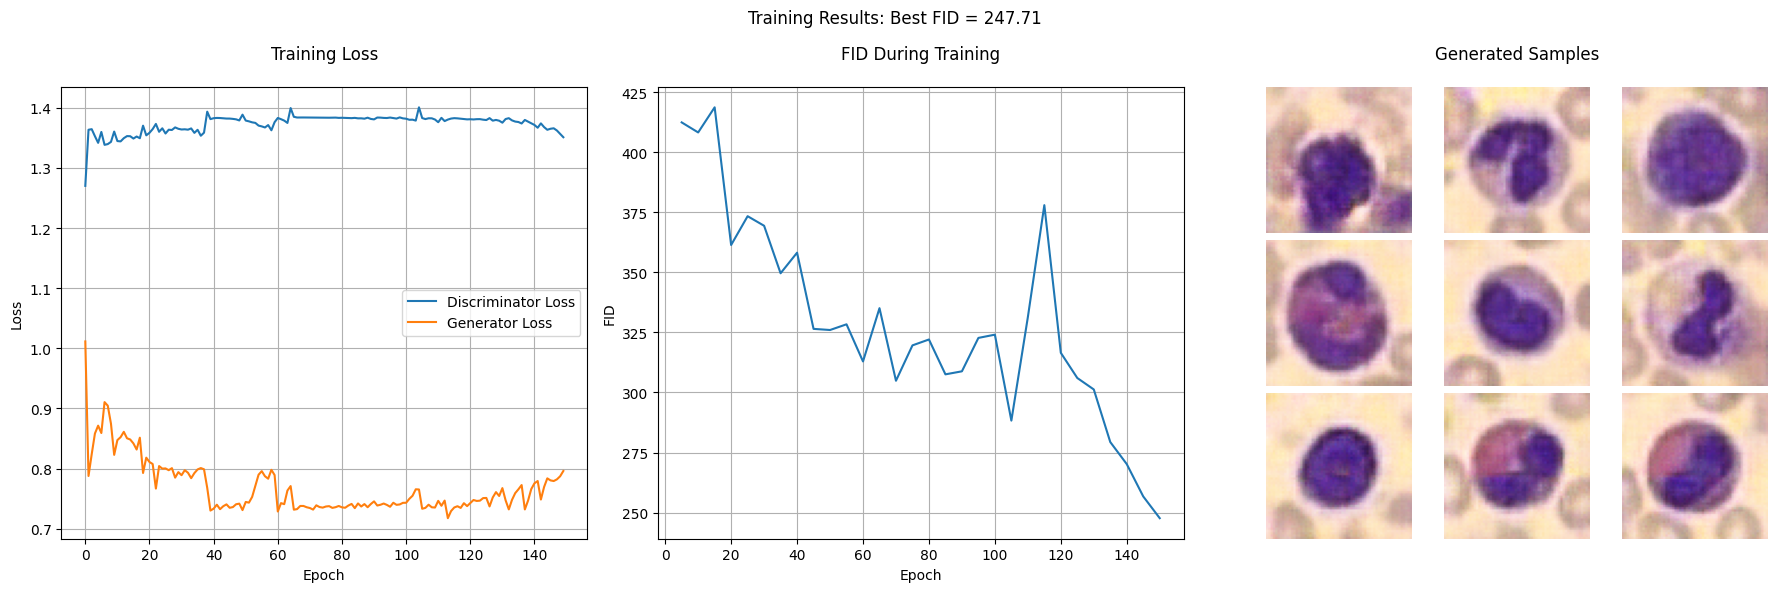

In [ ]:
# Create a wide figure with 3 subplots side-by-side
plt.figure(figsize=(18, 6))

gs = plt.GridSpec(1, 3, width_ratios=[1, 1, 1])  # Define a GridSpec layout with 3 equally sized columns

# === Subplot 1: Plot Generator and Discriminator Losses ===
ax1 = plt.subplot(gs[0])
ax1.plot(losses_D, label='Discriminator Loss')
ax1.plot(losses_G, label='Generator Loss')
ax1.set_title('Training Loss', pad=20)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# === Subplot 2: Plot FID Score Curve ===
if fid_scores:
    ax2 = plt.subplot(gs[1])
    ax2.plot(range(5, len(fid_scores)*5+1, 5), fid_scores)  # Plot FID every 5 epochs
    ax2.set_title('FID During Training', pad=20)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('FID')
    ax2.grid(True)

# === Subplot 3: Show a 3x3 Grid of Sample Images ===
ax3 = plt.subplot(gs[2])
ax3.set_title('Generated Samples', pad=20)
ax3.axis('off')  # Hide the axis frame

# Define a 3x3 subgrid inside the third subplot for 9 images
sub_gs = gs[2].subgridspec(3, 3, wspace=0.05, hspace=0.05)

# Randomly select 9 image files from the final image directory
sample_files = np.random.choice(os.listdir(final_images_dir), 9, replace=False)

# Loop through each position in the 3x3 grid
for i in range(9):
    row = i // 3
    col = i % 3
    ax_img = plt.subplot(sub_gs[row, col])
    img = plt.imread(os.path.join(final_images_dir, sample_files[i]))  # Load image
    ax_img.imshow(img)  # Show image in subplot
    ax_img.axis('off')

plt.suptitle(f'Training Results: Best FID = {best_fid:.2f}')
plt.tight_layout()

# Save the entire figure to disk
plot_path = os.path.join(project_path, 'training_results.png')
plt.savefig(plot_path)
plt.show()

## Save Training Results and Summary

Saves the final training metrics and model parameters after the DCGAN training is complete.

- Saves detailed results including losses, FID scores, and best epoch to a JSON file for future reference.
- Writes a human-readable summary text file with key results and training parameters.
- Records the number of saved model files, generated images, training plots, and TensorBoard logs.
- Closes the TensorBoard writer to finalize logging.
- Prints a summary of the training completion and the best final FID scores.


In [ ]:
# === Prepare Final Results Dictionary for Saving ===
results = {
    'best_fid': float(best_fid),
    'best_epoch': int(best_epoch),
    'final_fid': float(avg_fid),
    'final_fid_std': float(std_fid),
    'losses_D': [float(x) for x in losses_D],
    'losses_G': [float(x) for x in losses_G],
    'fid_scores': [float(x) for x in fid_scores],
    'final_fid_scores': [float(x) for x in final_fid_scores],
    'model_params': {
        'z_dim': 100,
        'lr': 1e-4,
        'epochs': 150,
    }
}

# === Save All Results as a JSON File ===
with open(os.path.join(project_path, 'training_results.json'), 'w') as f:
    json.dump(results, f, indent=4)  # Indented for readability

# === Save a Readable Summary to a Text File ===
with open(os.path.join(project_path, 'results_summary.txt'), 'w') as f:
    f.write(f"=== CGAN Training Results ===\n\n")
    f.write(f"Best FID: {best_fid:.2f} at epoch {best_epoch}\n")
    f.write(f"Final FID (10k samples): {avg_fid:.2f} ± {std_fid:.2f}\n\n")

    f.write(f"Training Parameters:\n")
    f.write(f"- Z dimension: 100\n")
    f.write(f"- Learning rate: 1e-4\n")
    f.write(f"- Epochs: 150\n")
    f.write(f"- Batch size: {batch_size}\n\n")

    f.write(f"Files saved:\n")
    f.write(f"- Models: {len(os.listdir(best_models))} files in {best_models}\n")
    f.write(f"- Generated images: {len(os.listdir(final_images_dir))} files in {final_images_dir}\n")
    f.write(f"- Training plots: {plot_path}\n")
    f.write(f"- TensorBoard logs: {logs_dir}\n")

# Close TensorBoard writer
writer.close()

print(f"\nTraining complete! All files saved to: {project_path}")
print(f"Best FID achieved: {best_fid:.2f} at epoch {best_epoch}")
print(f"Final FID (10k samples): {avg_fid:.2f} ± {std_fid:.2f}")


Training complete! All files saved to: /content/drive/MyDrive/ColabNotebooks/TP2/cGAN
Best FID achieved: 247.71 at epoch 150
Final FID (10k samples): 246.33 ± 0.50


# Hyperparameter Grid Search for Conditional GAN (cGAN)

This script performs a comprehensive **grid search** over multiple hyperparameter combinations to find the best configuration for training a conditional GAN (cGAN) on the full dataset.

## Parameters Explored

The grid search explores the following hyperparameters:

- **Latent vector dimension (`z_dim`)**:  
  Values: `100`, `128`

- **Number of feature maps in Generator/Discriminator (`feature_maps`)**:  
  Values: `64`, `128`

- **Discriminator learning rate (`lr_D`)**:  
  Values: `5e-5`, `1e-4`

- **Generator learning rate (`lr_G`)**:  
  Values: `5e-5`, `1e-4`

- **Batch size (`batch_size`)**:  
  Values: `128`, `256`

- **Embedding size (`embed_size`)** (for class conditioning):  
  Values: `50`, `100`

This results in a total of **64 unique hyperparameter combinations**.

## Training Setup

For each hyperparameter combination:

- A new **Generator** and **Discriminator** are initialized using the specified parameters.
- The model is trained for **25 epochs** using the full dataset.
- The training loop includes:
  - **Label smoothing**: Real labels are sampled from the interval `[0.9, 1.0]`.
  - **Label flipping**: With 5% probability, real and fake labels are swapped to regularize the Discriminator.
  - If the **Discriminator loss** becomes too low (below 0.01), an **extra Generator update** is performed to maintain balance.

### Optimizers and Loss

- Loss function: `BCEWithLogitsLoss`
- Optimizers: Adam with betas `(0.0, 0.9)` and individual learning rates for Generator and Discriminator

## Evaluation

After each configuration completes training:

- **Fréchet Inception Distance (FID)** is computed on **5,000 generated samples** to assess quality and diversity.
- The full training **loss history** and **FID score** are saved.

## Model Checkpointing

- If a configuration achieves a better FID than all previous ones:
  - The Generator, Discriminator, optimizer states, training history, and parameters are saved to:
    ```
    best_cgan_grid_search.pth
    ```
- This ensures only the best-performing model is preserved.

## Output

- A `grid_search_results.json` file is written to save all configurations, losses, and FID scores.
- The following is printed to the console at the end:
  - The **best FID** achieved
  - The **best hyperparameter configuration**
  - The **top 5 configurations** sorted by FID for quick comparison


In [ ]:
# === Define Grid of Hyperparameters to Search Over ===
param_grid = {
    'z_dim': [100, 128],  # Latent space dimensions
    'feature_maps': [64, 128],  # Number of feature maps in generator/discriminator
    'lr_D': [5e-5, 1e-4],  # Learning rates of the discriminator
    'lr_G': [5e-5, 1e-4],  # Learning rates of the generator
    'batch_size': [128, 256],  # Batch sizes
    'embed_size': [50, 100]  #
}

# Generate all combinations of hyperparameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
print(f"Total combinations: {len(all_params)}")

# Initialize tracking variables for best configuration
grid_best_fid = float('inf')
grid_best_model = None
grid_best_params = None
results = []  # Store history and FID for each config

# === Loop Over Each Hyperparameter Combination ===
for i, params in enumerate(all_params):
    print(f"\n=== Training combination {i+1}/{len(all_params)} ===")
    print("Parameters:", params)

    # Create dataloader with specified batch size
    dataloader = DataLoader(full_dataset, batch_size=params['batch_size'], shuffle=True)

    # Initialize generator and discriminator with current parameters
    generator = Generator(z_dim=params['z_dim'], num_classes=n_classes, feature_maps=params['feature_maps'], embed_size=params['embed_size']).to(device)
    discriminator = Discriminator(num_classes=n_classes, feature_maps=params['feature_maps']).to(device)

    # Set loss function and optimizers
    criterion = nn.BCEWithLogitsLoss()
    optimizer_G = optim.Adam(generator.parameters(), lr=params['lr_G'], betas=(0.0, 0.9))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=params['lr_D'], betas=(0.0, 0.9))

    # Track training history
    history = {
        'losses_D': [],
        'losses_G': [],
        'fid_scores': [],
    }

    num_epochs = 25
    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()

        total_loss_D = 0
        total_loss_G = 0

        # === Training Loop for One Epoch ===
        for real, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            real = real.to(device)
            labels = labels.squeeze().long().to(device)
            batch_size = real.size(0)

            real_labels = torch.empty(batch_size, device=device).uniform_(0.9, 1.0)
            fake_labels = torch.zeros(batch_size, device=device)

            if torch.rand(1).item() < 0.05:
                real_labels, fake_labels = fake_labels.clone(), real_labels.clone()

            # --- Train Discriminator ---
            z = torch.randn(batch_size, params['z_dim'], device=device)
            fake_images = generator(z, labels)

            real_pred = discriminator(real, labels)
            fake_pred = discriminator(fake_images.detach(), labels)

            loss_D_real = criterion(real_pred, real_labels)
            loss_D_fake = criterion(fake_pred, fake_labels)
            loss_D = loss_D_real + loss_D_fake

            total_loss_D += loss_D.item()

            optimizer_D.zero_grad()
            loss_D.backward()
            optimizer_D.step()

            # --- Train Generator ---
            z = torch.randn(batch_size, params['z_dim'], device=device)
            fake_images = generator(z, labels)
            pred = discriminator(fake_images, labels)

            loss_G = criterion(pred, real_labels)  # Generator wants to fool discriminator
            total_loss_G += loss_G.item()

            optimizer_G.zero_grad()
            loss_G.backward()
            optimizer_G.step()

            # If discriminator is too confident (loss below threshold), train generator again to rebalance
            if loss_D.item() < 0.01:
                z = torch.randn(batch_size, params['z_dim'], device=device)
                fake_images = generator(z, labels)
                pred = discriminator(fake_images, labels)
                loss_G_extra = criterion(pred, real_labels)

                optimizer_G.zero_grad()
                loss_G_extra.backward()
                optimizer_G.step()

        # Record average losses
        avg_loss_D = total_loss_D / len(dataloader)
        avg_loss_G = total_loss_G / len(dataloader)
        history['losses_D'].append(avg_loss_D)
        history['losses_G'].append(avg_loss_G)

        print(f"\tLoss Discriminator: {avg_loss_D:.4f} - Loss Generator: {avg_loss_G:.4f}")

    # === Compute FID for This Model ===
    fid = compute_fid_safe(generator, num_classes=n_classes, num_samples=5000, z_dim=params['z_dim'])
    history['fid_scores'].append(fid)
    print(f"FID: {fid:.2f}")

    # Store results
    results.append({
        'params': params,
        'history': history,
        'fid': fid,
    })

    # Save best model so far
    if fid < grid_best_fid:
        grid_best_fid = fid
        grid_best_model = generator
        grid_best_params = params

        torch.save({
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'params': params,
            'optimizer_state_dict_D': optimizer_D.state_dict(),
            'optimizer_state_dict_G': optimizer_G.state_dict(),
            'history': history,
            'fid': fid,
        }, os.path.join(best_grid_models, f'best_cgan_grid_search.pth'))

# === Final Reporting ===
print("\n=== Grid Search Complete ===")
print(f"Best FID: {grid_best_fid:.2f}")
print("Best parameters:")
print(grid_best_params)

# Save all results as JSON
with open(os.path.join(project_path, 'grid_search_results.json'), 'w') as f:
    json.dump(results, f, indent=4)

# Print top 5 configurations by FID
sorted_results = sorted(results, key=lambda x: x['fid'])
print("\nTop 5 configurations:")
for i, res in enumerate(sorted_results[:5]):
    print(f"{i+1}. FID: {res['fid']:.2f} - Params: {res['params']}")

Total combinations: 64

=== Training combination 1/64 ===
Parameters: {'z_dim': 100, 'feature_maps': 64, 'lr_D': 5e-05, 'lr_G': 5e-05, 'batch_size': 128, 'embed_size': 50}


Epoch 1/25: 100%|██████████| 134/134 [00:09<00:00, 13.64it/s]


	Loss Discriminator: 0.9796 - Loss Generator: 1.3422


Epoch 2/25: 100%|██████████| 134/134 [00:09<00:00, 13.62it/s]


	Loss Discriminator: 1.3066 - Loss Generator: 0.8363


...

	Loss Discriminator: 1.3689 - Loss Generator: 0.7814


Epoch 24/25: 100%|██████████| 67/67 [00:10<00:00,  6.57it/s]


	Loss Discriminator: 1.3588 - Loss Generator: 0.8019


Epoch 25/25: 100%|██████████| 67/67 [00:10<00:00,  6.60it/s]


	Loss Discriminator: 1.3660 - Loss Generator: 0.7903
FID: 360.09

=== Grid Search Complete ===
Best FID: 280.33
Best parameters:
{'z_dim': 100, 'feature_maps': 128, 'lr_D': 0.0001, 'lr_G': 0.0001, 'batch_size': 128, 'embed_size': 100}

Top 5 configurations:
1. FID: 280.33 - Params: {'z_dim': 100, 'feature_maps': 128, 'lr_D': 0.0001, 'lr_G': 0.0001, 'batch_size': 128, 'embed_size': 100}
2. FID: 289.44 - Params: {'z_dim': 128, 'feature_maps': 128, 'lr_D': 0.0001, 'lr_G': 0.0001, 'batch_size': 128, 'embed_size': 100}
3. FID: 291.38 - Params: {'z_dim': 100, 'feature_maps': 128, 'lr_D': 0.0001, 'lr_G': 0.0001, 'batch_size': 128, 'embed_size': 50}
4. FID: 298.22 - Params: {'z_dim': 128, 'feature_maps': 128, 'lr_D': 0.0001, 'lr_G': 0.0001, 'batch_size': 128, 'embed_size': 50}
5. FID: 329.25 - Params: {'z_dim': 128, 'feature_maps': 128, 'lr_D': 5e-05, 'lr_G': 0.0001, 'batch_size': 128, 'embed_size': 100}


# Load Best Grid Search Model and Continue Training

Loads the best model found during the hyperparameter grid search and prepares it for further training:

- Loads checkpoint containing the best generator and discriminator state dictionaries, best hyperparameters, and best FID score.
- Recreates the data loader with the best batch size.
- Instantiates the generator and discriminator models with the best found parameters.
- Sets up the loss function (BCEWithLogitsLoss) and Adam optimizers with the best learning rate.
- Continues training the DCGAN for 150 epochs starting from the saved checkpoint to further improve performance.
- Saves intermediate checkpoints and logs in the specified directories for monitoring.

In [11]:
# === Load Best Model Checkpoint from Grid Search ===
grid_model_path = os.path.join(best_grid_models, f'best_cgan_grid_search.pth')
checkpoint = torch.load(grid_model_path)

# Extract generator and discriminator weights, best params, and FID score
best_generator = checkpoint['generator_state_dict']
best_discriminator = checkpoint['discriminator_state_dict']
best_params = checkpoint['params']
best_fid = checkpoint['fid']

# === Prepare DataLoader with Best Batch Size ===
dataloader = DataLoader(full_dataset, batch_size=best_params['batch_size'], shuffle=True)

# === Re-initialize Models Using Best Parameters ===
generator = Generator(z_dim=best_params['z_dim'], num_classes=n_classes, feature_maps=best_params['feature_maps'], embed_size=best_params['embed_size']).to(device)
discriminator = Discriminator(num_classes=n_classes, feature_maps=best_params['feature_maps']).to(device)

# === Define Loss Function and Optimizers Using Best Learning Rate ===
criterion = nn.BCEWithLogitsLoss()
optimizer_G = optim.Adam(generator.parameters(), lr=best_params['lr_G'], betas=(0.0, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=best_params['lr_D'], betas=(0.0, 0.9))

# === Retrain the DCGAN Using the Best Found Configuration ===
# Run for 150 epochs and save model checkpoints to specified directories
grid_losses_D, grid_losses_G, grid_fid_scores, grid_best_fid, grid_best_epoch = train_cgan(dataloader, z_dim=best_params['z_dim'], epochs=150, m_dir=best_grid_models, c_dir=grid_checkpoints)

Epoch 5/150: 100%|██████████| 134/134 [00:10<00:00, 12.73it/s]
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:02<00:00, 42.3MB/s]


Epoch 5/150: 
	Loss D: 1.3632, Loss G: 0.8447, FID: 411.08


Epoch 10/150: 100%|██████████| 134/134 [00:10<00:00, 12.40it/s]


Epoch 10/150: 
	Loss D: 1.3569, Loss G: 0.8394, FID: 373.17


Epoch 15/150: 100%|██████████| 134/134 [00:10<00:00, 12.43it/s]


...

Epoch 140/150: 
	Loss D: 1.2785, Loss G: 0.8563, FID: 162.83


Epoch 145/150: 100%|██████████| 134/134 [00:10<00:00, 12.29it/s]


Epoch 145/150: 
	Loss D: 1.2935, Loss G: 0.8415, FID: 156.75


Epoch 150/150: 100%|██████████| 134/134 [00:10<00:00, 12.32it/s]


Epoch 150/150: 
	Loss D: 1.2790, Loss G: 0.8528, FID: 153.17


## Load Best Grid Search Model Checkpoint and Perform Final Evaluation

- Loads the best saved model checkpoint based on the epoch and FID score.
- Loads the generator weights and sets it to evaluation mode.
- Generates 10,000 images in batches, saving them to a designated directory.
- Runs the final FID evaluation 5 times with 10,000 generated samples each run to get a robust estimate.
- Sets random seeds before each run for reproducibility.
- Calculates and prints the mean and standard deviation of the FID scores across the runs.


In [14]:
# Construct the path to the best model checkpoint saved during grid search
grid_best_model_path = os.path.join(best_grid_models, f'best_cgan_epoch{grid_best_epoch}_fid{grid_best_fid:.2f}.pth')
checkpoint = torch.load(grid_best_model_path)  # Load the checkpoint containing the best model weights and other info
generator.load_state_dict(checkpoint['generator_state_dict'])  # Load the generator weights from the checkpoint
generator.eval()  # Set generator to evaluation mode

# Final Evaluation and Image Generation
print("\nGenerating 10,000 images for final evaluation...")
grid_final_images_dir = os.path.join(images_dir, 'final_10k_grid')
os.makedirs(grid_final_images_dir, exist_ok=True)

# Generate in batches to save memory
with torch.no_grad():
    for i in tqdm(range(0, 10000, batch_size)):
        current_batch_size = min(batch_size, 10000-i)

        z = torch.randn(current_batch_size, 100, device=device)  # Changed from 4D to 2D for cGAN
        labels = torch.randint(0, n_classes, (current_batch_size,), device=device)  # Random class labels

        images = generator(z, labels)
        images = (images + 1) / 2  # Scale images from [-1, 1] range to [0, 1] for saving

        for j in range(images.shape[0]):
            save_image(images[j], os.path.join(grid_final_images_dir, f"img_{i+j:05d}.png"))

# Final FID evaluation (5 runs)
print("\nRunning final FID evaluation (5 runs with 10k samples)...")
grid_final_fid_scores = []  # Initialize list to hold FID scores from multiple runs

# Run FID evaluation 5 times with different random seeds for robustness
for run in range(5):
    print(f"\nRun {run+1}/5")

    torch.manual_seed(run)
    np.random.seed(run)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run)

    try:
        # Compute FID score for the generator using 10,000 generated samples
        fid = compute_fid_safe(generator, num_classes=n_classes, num_samples=10000, batch_size=batch_size)
        grid_final_fid_scores.append(fid)  # Store the computed FID score
        print(f"FID = {fid:.2f}")
        torch.cuda.empty_cache()  # Clear CUDA cache to free memory between runs

    except Exception as e:
        print(f"Error in run {run+1}: {str(e)}")
        continue

# After all runs, compute and print mean and standard deviation of FID scores
if grid_final_fid_scores:
    grid_avg_fid = np.mean(grid_final_fid_scores)
    grid_std_fid = np.std(grid_final_fid_scores)
    print(f"\nFinal FID: {grid_avg_fid:.2f} ± {grid_std_fid:.2f}")

else:
    print("Failed to compute FID in all runs.")
    grid_avg_fid = float('inf')
    grid_std_fid = 0


Generating 10,000 images for final evaluation...


100%|██████████| 40/40 [00:57<00:00,  1.43s/it]



Running final FID evaluation (5 runs with 10k samples)...

Run 1/5
FID = 146.44

Run 2/5
FID = 146.15

Run 3/5
FID = 148.28

Run 4/5
FID = 146.42

Run 5/5
FID = 147.66

Final FID: 146.99 ± 0.83


## Visualize Grid Search Training Results

Generates a visualization of the training process and final outputs:

1. **Training Loss Curves:**  
   Plots discriminator and generator losses across epochs to monitor training stability and convergence.

2. **FID Score Curve:**  
   Shows the FID metric progression during training, evaluated every 5 epochs, to track model quality improvements.

3. **Generated Sample Images:**  
   Displays a 3x3 grid of randomly selected generated images from the final 10,000 samples, providing a qualitative sense of the generator’s performance.

The figure is saved as `grid_training_results.png` inside the project directory.


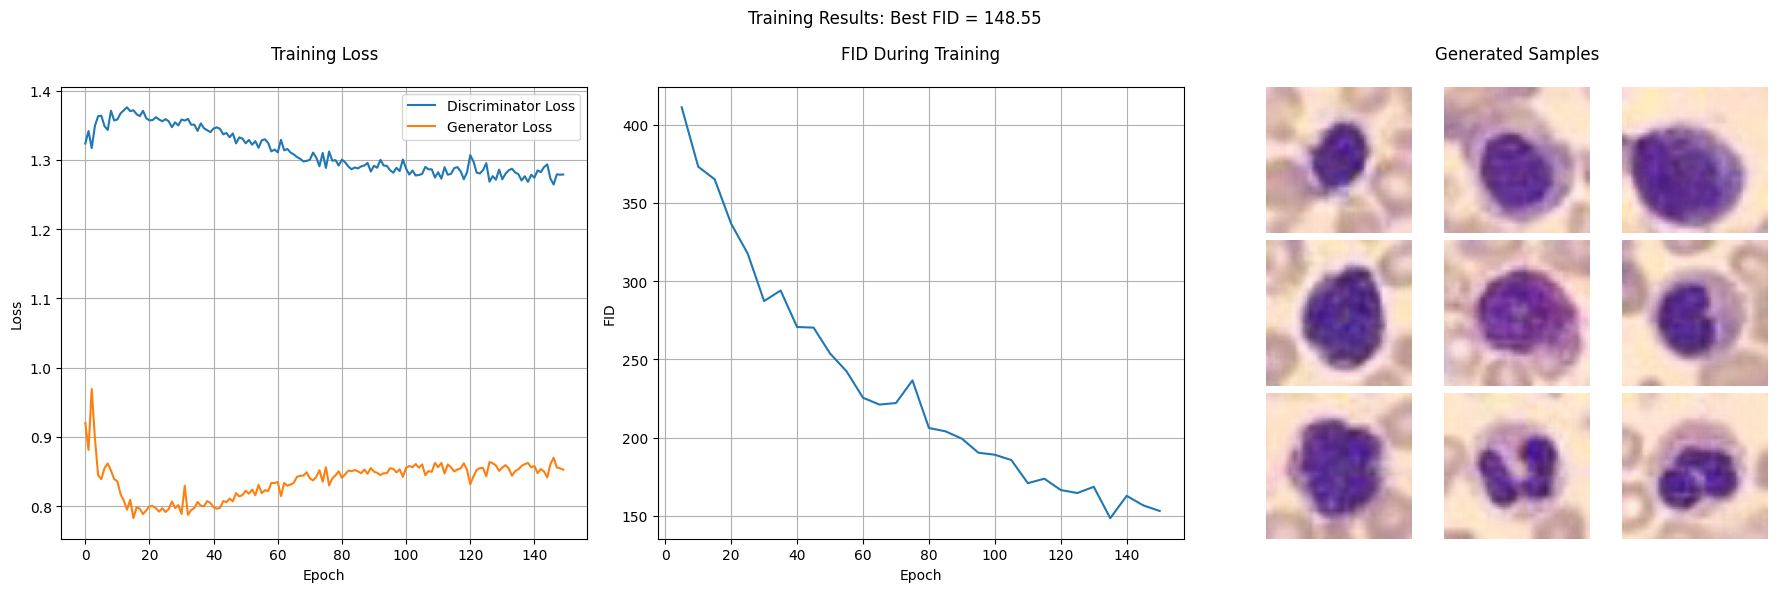

In [15]:
plt.figure(figsize=(18, 6))

# Create a grid layout with 1 row and 3 columns, each subplot equally sized
gs = plt.GridSpec(1, 3, width_ratios=[1, 1, 1])

# Subplot 1: Plot training losses for discriminator and generator
ax1 = plt.subplot(gs[0])
ax1.plot(grid_losses_D, label='Discriminator Loss')
ax1.plot(grid_losses_G, label='Generator Loss')
ax1.set_title('Training Loss', pad=20)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Subplot 2: Plot FID scores recorded during training (every 5 epochs)
if grid_fid_scores:
    ax2 = plt.subplot(gs[1])
    ax2.plot(range(5, len(grid_fid_scores)*5+1, 5), grid_fid_scores)
    ax2.set_title('FID During Training', pad=20)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('FID')
    ax2.grid(True)

# Subplot 3: Display a 3x3 grid of sample generated images
ax3 = plt.subplot(gs[2])
ax3.set_title('Generated Samples', pad=20)
ax3.axis('off')

sub_gs = gs[2].subgridspec(3, 3, wspace=0.05, hspace=0.05)

# Randomly select 9 image filenames from the directory of generated images
grid_sample_files = np.random.choice(os.listdir(grid_final_images_dir), 9, replace=False)

# Loop over the 9 chosen images to load and display each in the subgrid
for i in range(9):
    row = i // 3
    col = i % 3
    ax_img = plt.subplot(sub_gs[row, col])
    img = plt.imread(os.path.join(grid_final_images_dir, grid_sample_files[i]))
    ax_img.imshow(img)
    ax_img.axis('off')

plt.suptitle(f'Training Results: Best FID = {grid_best_fid:.2f}')
plt.tight_layout()

plot_path = os.path.join(project_path, 'grid_training_results.png')
plt.savefig(plot_path)
plt.show()

## Save Final Grid Search Results

Compiles all the important metrics, training losses, and parameters from the grid search and final evaluation into a dictionary.

- Saves the results as a JSON file (`grid_training_results.json`) for easy access.
- Saves a text summary (`grid_results_summary.txt`) containing key training statistics and file counts for quick human reference.
- Closes the TensorBoard writer to finalize logging.

Finally, it prints out the best FID score, epoch, and final evaluation FID with standard deviation, confirming that all files were saved successfully.


In [16]:
# Save Final Results
results = {
    'grid_best_fid': float(grid_best_fid),
    'grid_best_epoch': int(grid_best_epoch),
    'grid_final_fid': float(grid_avg_fid),
    'grid_final_fid_std': float(grid_std_fid),
    'grid_losses_D': [float(x) for x in grid_losses_D],
    'grid_losses_G': [float(x) for x in grid_losses_G],
    'grid_fid_scores': [float(x) for x in grid_fid_scores],
    'grid_final_fid_scores': [float(x) for x in grid_final_fid_scores],
    'grid_model_params': {
        'z_dim': best_params['z_dim'],
        'lr_D': best_params['lr_D'],
        'lr_G': best_params['lr_G'],
        'embed_size': best_params['embed_size'],
        'feature_maps': best_params['feature_maps'],
        'epochs': 150,
    }
}

# Save results as json file
with open(os.path.join(project_path, 'grid_training_results.json'), 'w') as f:
    json.dump(results, f, indent=4)

# Save results as text file
with open(os.path.join(project_path, 'grid_results_summary.txt'), 'w') as f:
    f.write(f"=== Final DCGAN Training Results ===\n\n")
    f.write(f"Best FID: {grid_best_fid:.2f} at epoch {grid_best_epoch}\n")
    f.write(f"Final FID (10k samples): {grid_avg_fid:.2f} ± {grid_std_fid:.2f}\n\n")
    f.write(f"Training Parameters:\n")
    f.write(f"- Z dimension: {best_params['z_dim']}\n")
    f.write(f"- Learning rate of the Discriminator: {best_params['lr_D']}\n")
    f.write(f"- Learning rate of the Generator: {best_params['lr_G']}\n")
    f.write(f"- Embedding size: {best_params['embed_size']}\n")
    f.write(f"- Number of feature maps: {best_params['feature_maps']}\n")
    f.write(f"- Epochs: 150\n")
    f.write(f"- Batch size: {batch_size}\n\n")
    f.write(f"Files saved:\n")
    f.write(f"- Models: {len(os.listdir(best_grid_models))} files in {best_grid_models}\n")
    f.write(f"- Generated images: {len(os.listdir(grid_final_images_dir))} files in {grid_final_images_dir}\n")
    f.write(f"- Training plots: {plot_path}\n")
    f.write(f"- TensorBoard logs: {logs_dir}\n")

# Close TensorBoard writer
writer.close()

print(f"\nTraining complete! All files saved to: {project_path}")
print(f"Best FID achieved: {grid_best_fid:.2f} at epoch {grid_best_epoch}")
print(f"Final FID (10k samples): {grid_avg_fid:.2f} ± {grid_std_fid:.2f}")


Training complete! All files saved to: /content/drive/MyDrive/ColabNotebooks/TP2/cGAN
Best FID achieved: 148.55 at epoch 135
Final FID (10k samples): 146.99 ± 0.83
